<a href="https://colab.research.google.com/github/rapaaal/Project-with-Google-Collab/blob/main/Sistem_Deteksi_Dini_Kegagalan_Roda_Kereta_Api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistem Deteksi Dini Kegagalan Roda Kereta Api berdasarkan signature getaran (vibration) dan suhu (temperature)




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

# Atur seed agar hasil konsisten
np.random.seed(42)
tf.random.set_seed(42)

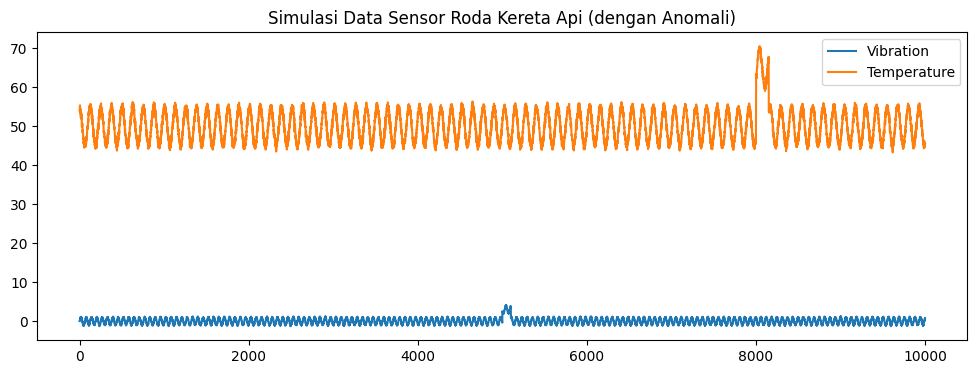

In [3]:
# Generate data normal (sinyal periodik + noise)
time = np.arange(0, 1000, 0.1)
vibration = np.sin(time) + np.random.normal(0, 0.1, len(time))
temperature = 50 + 5 * np.cos(time / 2) + np.random.normal(0, 0.5, len(time))

# Sisipkan anomali (Spike pada getaran & lonjakan suhu) di indeks tertentu
vibration[5000:5100] += 3.0  # Anomali getaran mekanis
temperature[8000:8150] += 15.0 # Anomali overheat

# Buat DataFrame
df = pd.DataFrame({'vibration': vibration, 'temperature': temperature})

plt.figure(figsize=(12, 4))
plt.plot(df['vibration'], label='Vibration')
plt.plot(df['temperature'], label='Temperature')
plt.title("Simulasi Data Sensor Roda Kereta Api (dengan Anomali)")
plt.legend()
plt.show()

In [4]:
# 1. Normalisasi Data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2. Fungsi Windowing (membuat sekuens)
def create_sequences(data, time_steps=30):
    Xs = []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
    return np.array(Xs)

TIME_STEPS = 30
X_train = create_sequences(df_scaled[:4000], TIME_STEPS) # Hanya data normal untuk training
X_test = create_sequences(df_scaled, TIME_STEPS)         # Seluruh data (termasuk anomali) untuk testing

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (3970, 30, 2)
Shape X_test: (9970, 30, 2)


Arsitektur LSTM

In [5]:
model = Sequential([
    # ENCODER
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    LSTM(32, activation='relu', return_sequences=False),

    # BOTTLENECK LAYER
    RepeatVector(X_train.shape[1]),

    # DECODER
    LSTM(32, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X_train.shape[2]))
])

model.compile(optimizer='adam', loss='mae')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,850 (245.51 KB)

 Trainable params: 62,850 (245.51 KB)

 Non-trainable params: 0 (0.00 B)

Training Model

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.4777 - val_loss: 0.2791
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2157 - val_loss: 0.1632
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1452 - val_loss: 0.1255
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1218 - val_loss: 0.1200
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1148 - val_loss: 0.1104
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1096 - val_loss: 0.1059
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1073 - val_loss: 0.1054
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1073 - val_loss: 0.1054
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1049 - val_loss: 0.1073
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1048 - val_loss: 0.1048
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1055 - val_loss: 0.1055
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━

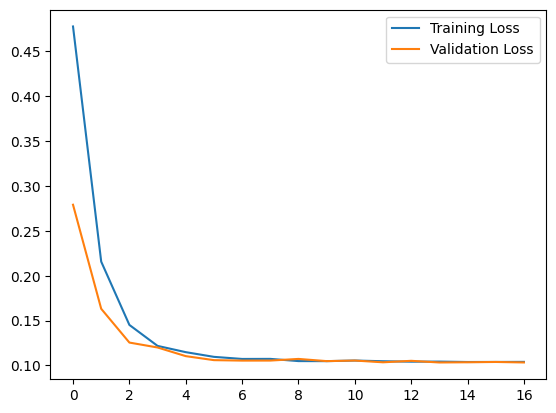

In [6]:
history = model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')]
)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

Evaluasi Threshold Anomali

In [7]:
# Prediksi/Rekonstruksi data train
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1)

# Ambil nilai max loss dari data normal sebagai threshold
THRESHOLD = np.max(train_mae_loss)
print(f"Reconstruction error threshold: {THRESHOLD}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Reconstruction error threshold: 0.1449195528390255


Evaluation

312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


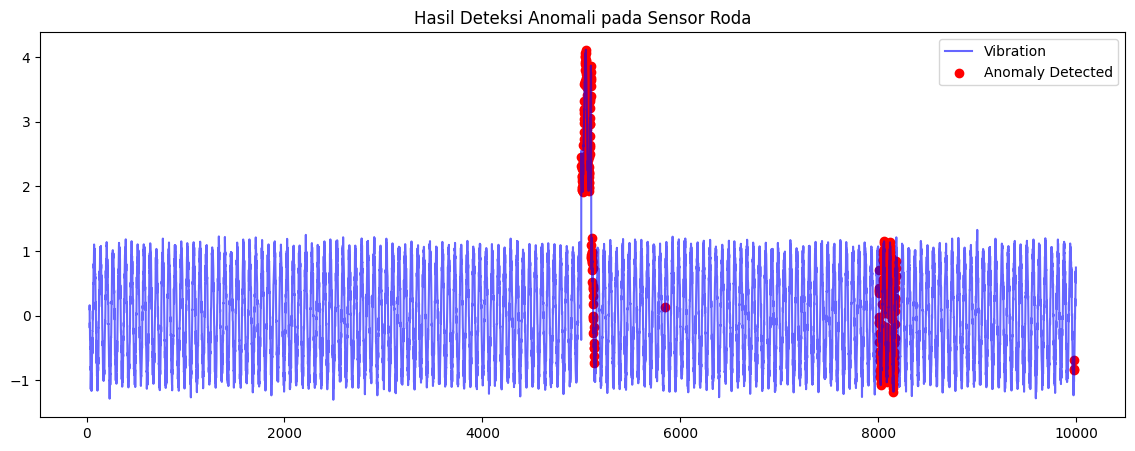

In [12]:
# Prediksi data uji
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)

# Deteksi anomali
anomalies = test_mae_loss > THRESHOLD

# Siapkan data untuk divisualisasikan
anomalous_data_indices = []
for data_idx in range(TIME_STEPS - 1, len(X_test) - TIME_STEPS + 1):
    if anomalies[data_idx].any():
        anomalous_data_indices.append(data_idx)

df_subset = df.iloc[TIME_STEPS:]

plt.figure(figsize=(14, 5))
plt.plot(df_subset.index, df_subset['vibration'], label='Vibration', color='blue', alpha=0.6)
plt.scatter(df_subset.index[anomalies[:,0]], df_subset['vibration'].iloc[anomalies[:,0]], color='red', label='Anomaly Detected')
plt.title("Hasil Deteksi Anomali pada Sensor Roda")
plt.legend()
plt.show()